
## **Introduction**

Market Basket Analysis (MBA) is a data mining technique used to discover relationships between items that customers frequently purchase together. One of the most widely used algorithms for this task is the Apriori algorithm, which identifies frequent itemsets and generates association rules based on measures such as support, confidence, and lift. These measures help determine how often products are purchased together, how reliable the relationships are, and whether the associations are stronger than would be expected by chance.

In this notebook, the BreadBasket_DMS.csv dataset is used to perform Market Basket Analysis on transactions from a bakery. The dataset contains customer purchase records, where each transaction consists of one or more products bought during a single visit. By applying the Apriori algorithm, we identify frequent product combinations and uncover meaningful purchasing patterns.

The results are presented through a series of data visualizations that illustrate frequent itemsets, association rules, network relationships, rule quality, and product interactions. These visualizations provide valuable business insights for product bundling, cross-selling, recommendation systems, shelf placement optimization, and promotional planning, enabling data-driven decision-making in retail environments.

- Data: https://www.kaggle.com/datasets/hsowdahsowda/breadbasket-dms-csv
  

In [112]:
# pip install squarify
# pip install wordcloud
# pip install mlxtend
# pip install plotly
# pip install networkx

In [141]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
from wordcloud import WordCloud
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import plotly.graph_objects as go
import networkx as nx

# For good looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

In [113]:
#load data
df = pd.read_csv('BreadBasket_DMS.csv')
df.head()

,Date,Time,Transaction,Item
0,10/30/2016,9:58:11,1,Bread
1,10/30/2016,10:05:34,2,Scandinavian
2,10/30/2016,10:05:34,2,Scandinavian
3,10/30/2016,10:07:57,3,Hot chocolate
4,10/30/2016,10:07:57,3,Jam


## Data Discovery

In [114]:
df.shape

(21293, 4)

In [120]:
df.columns.tolist()

['Date', 'Time', 'Transaction', 'Item']

In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21293 entries, 0 to 21292
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         21293 non-null  str  
 1   Time         21293 non-null  str  
 2   Transaction  21293 non-null  int64
 3   Item         21293 non-null  str  
dtypes: int64(1), str(3)
memory usage: 665.5 KB


## Data Preparation

In [122]:
transactions = df.groupby('Transaction')['Item'].apply(list).reset_index()

This step groups all items purchased in the same transaction into a single list, creating a basket of products for each customer purchase.

In [194]:
# Convert to basket format (one-hot encoded)
te = TransactionEncoder()
te_ary = te.fit_transform(transactions['Item'])
basket = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Basket shape: {basket.shape}")


Basket shape: (9531, 95)


This step converts the transaction data into a one-hot encoded basket format, where each row represents a transaction and each column represents a product, with True indicating the item was purchased and False otherwise.

## Exploratory Visualizations + Explanations

###  1.1 Transaction Size Distribution

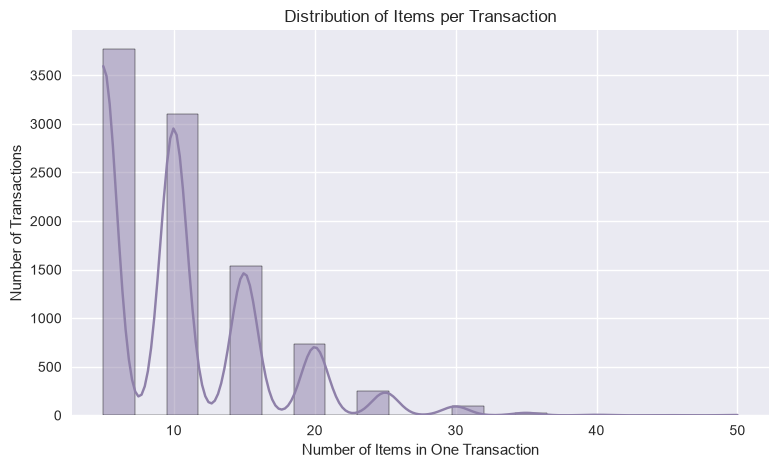

In [128]:
# Calculate number of items in each transaction (basket size)
basket['basket_size'] = basket.sum(axis=1)
plt.figure(figsize=(9, 5))
sns.histplot(basket['basket_size'], bins=20, kde=True, color='#8E80A9')
# Plot distribution of basket sizes
plt.title('Distribution of Items per Transaction')
plt.xlabel('Number of Items in One Transaction')
plt.ylabel('Number of Transactions')
plt.show()

This shows how many items customers typically buy together. A right-skewed distribution (most transactions have 1–4 items). Helps to understand average basket size and detect unusual large orders.

### 1.2 Top Items by Frequency

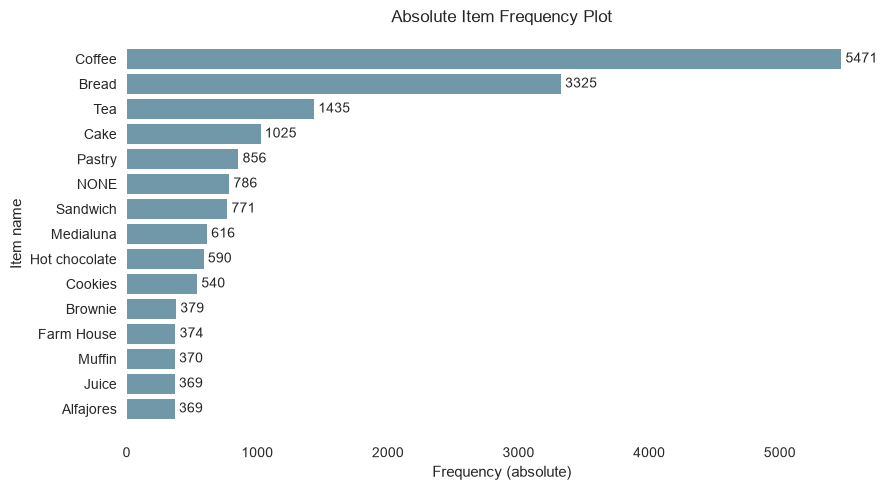

In [133]:
# Get top 15 most frequent items
item_counts = df['Item'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

# Create ahoriztal bar chart for item frq
bars = ax.barh(
    item_counts.index,
    item_counts.values,
    color='#7198A9',
    edgecolor='black',
    linewidth=0.0
)
ax.bar_label(bars, padding=3)
ax.set_title("Absolute Item Frequency Plot")
ax.set_xlabel("Frequency (absolute)")
ax.set_ylabel("Item name")
ax.invert_yaxis()
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

**Key insights:**

- Coffee is the most purchased item (5471 times), making it the dominant product by a large margin.
- Bread (3325) is the second most popular item, followed by Tea (1435).
- Items like Cake, Pastry, Sandwich, and Hot Chocolate form the mid-range group of purchases.
- The lower end (e.g., Muffin, Juice, Alfajores) shows relatively low but steady demand.

### 1.3 Transactions per Month

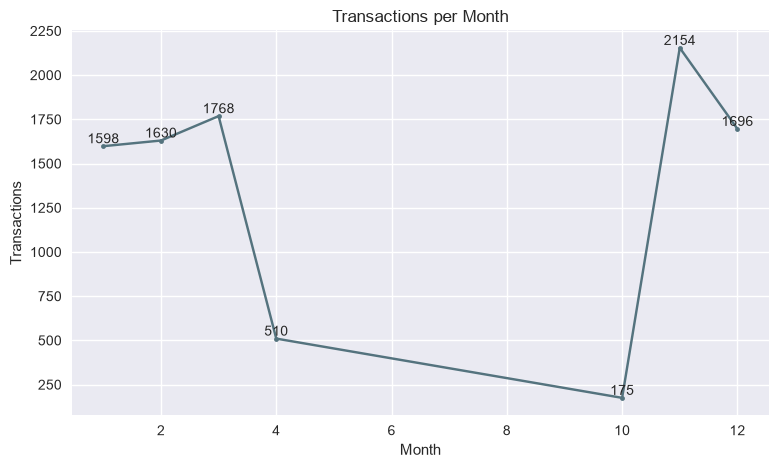

In [139]:
# Extract month from Date and count unique transactions per month
m = df.assign(Month=pd.to_datetime(df['Date']).dt.month)\
      .groupby('Month')['Transaction'].nunique()
plt.figure(figsize=(9,5))
plt.plot(m.index, m.values, marker='.', color='#54737E')
for x, y in zip(m.index, m.values):
    
    # Plot monthly transaction counts
    plt.text(x, y, y, ha='center', va='bottom')

plt.xlabel('Month')
plt.ylabel('Transactions')
plt.title('Transactions per Month')
plt.show()

Transaction frequency peaked in month 11 (2,154) and reached its minimum in month 10 (175), indicating significant seasonal variation in transaction activity.

### 1.4 Transactions per weekday

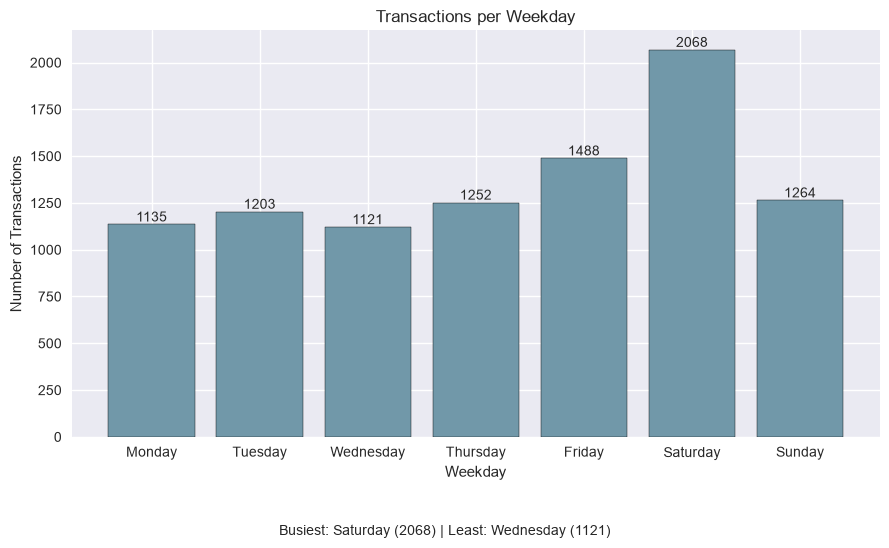

In [147]:
# Create weekday and compute unique transactions per day
weekly = (
    df.assign(Weekday=pd.to_datetime(df['Date']).dt.day_name())
      .groupby('Weekday')['Transaction']
      .nunique()
      .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
)

plt.figure(figsize=(9,5))

# Bar chart
bars = plt.bar(weekly.index, weekly.values, color='#7198A9', edgecolor='black')

# Add value labels on bars
for i, v in enumerate(weekly.values):
    plt.text(i, v, v, ha='center', va='bottom')

plt.title('Transactions per Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Transactions')

# Summary stats (busiest and least busy day)
plt.figtext(
    0.5, -0.08,
    f"Busiest: {weekly.idxmax()} ({weekly.max()}) | "
    f"Least: {weekly.idxmin()} ({weekly.min()})",
    ha='center'
)

plt.tight_layout()
plt.show()

Saturday recorded the highest transaction volume (2,068), while Wednesday had the lowest (1,121). Transaction activity generally increased toward the weekend, indicating higher customer engagement on Saturdays.

### 1.5 Transaction Distribution by Hour of Day

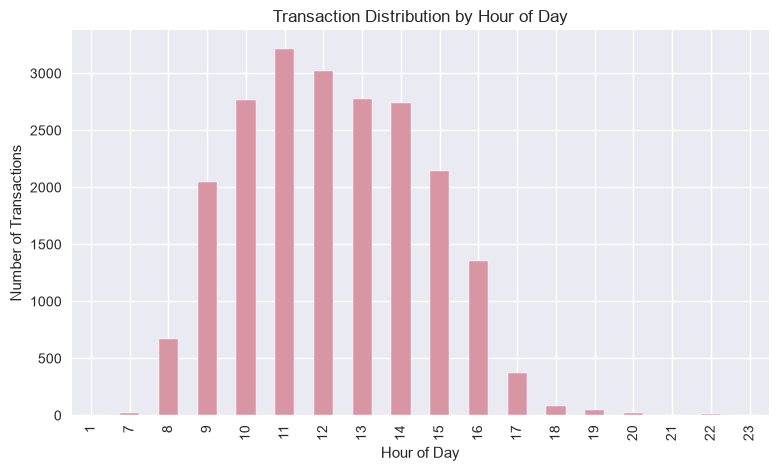

In [155]:
plt.figure(figsize=(9,5))
# Convert Time column to datetime format and extract the hour (0–23)
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
# Count transactions per hour and sort by hour order
df['Hour'].value_counts().sort_index().plot(
    kind='bar',
    color='#D895A3',
    edgecolor='white'
)

# chart title and axis labels
plt.title('Transaction Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.show()

Transaction activity peaked at 11:00 AM and remained high between 10:00 AM and 3:00 PM before declining sharply after 4:00 PM. This indicates that most transactions occurred during normal business hours.

### Data Backets

In [157]:
# group items by transaction
basket = df.groupby('Transaction')['Item'].apply(list).tolist()

# one-hot encode
te = TransactionEncoder()
te_array = te.fit(basket).transform(basket)

basket_df = pd.DataFrame(te_array, columns=te.columns_)
basket_df.head(1)

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Applying Apriori Algorith

In [158]:
# Generate frequent itemsets using the Apriori algorithm
# min_support=0.05 means only item combinations that appear in at least 5% of transactions are kept
frequent_itemsets = apriori(
    basket_df,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets.sort_values(
    by='support',
    ascending=False,
    inplace=True
)

frequent_itemsets.sort_values('support', ascending=False).head(10)

,support,itemsets
2,0.475081,frozenset({Coffee})
0,0.324940,frozenset({Bread})
9,0.141643,frozenset({Tea})
1,0.103137,frozenset({Cake})
10,0.089393,"frozenset({Coffee, Bread})"
7,0.085510,frozenset({Pastry})
6,0.079005,frozenset({NONE})
8,0.071346,frozenset({Sandwich})
5,0.061379,frozenset({Medialuna})
4,0.057916,frozenset({Hot chocolate})


After applying the Apriori algorithm, the results show the most frequently purchased itemsets based on support, with Coffee (47.5%) being the most dominant single item, followed by Bread (32.5%) and Tea (14.2%). It also identifies a strong association between items such as Coffee and Bread (8.9% support), meaning they are often bought together compared to other combinations.

### Generate Association Rules

In [159]:
# Generate association rules using confidence as the evaluation metric
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.02
)
# key metrics for interpretation of rules
rules[['antecedents','consequents','support','confidence','lift']].head()

,antecedents,consequents,support,confidence,lift
0,frozenset({Coffee}),frozenset({Bread}),0.089393,0.188163,0.579069
1,frozenset({Bread}),frozenset({Coffee}),0.089393,0.275105,0.579069
2,frozenset({Coffee}),frozenset({Cake}),0.054349,0.114399,1.109196
3,frozenset({Cake}),frozenset({Coffee}),0.054349,0.526958,1.109196


These association rules show how items are related in purchase behavior. For example, Cake → Coffee has a relatively strong confidence of 52.7% with a lift of 1.11, meaning Cake buyers are moderately more likely to also buy Coffee than by chance. However, Coffee ↔ Bread has low lift (0.58) in both directions, indicating a weak or even negative association, despite Coffee being frequently purchased overall.

### Interpret the Results

### Try Different Support Levels

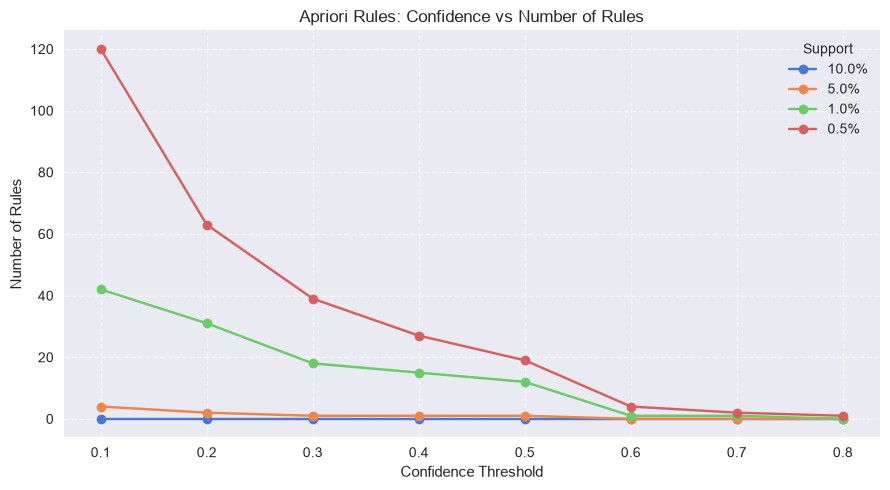

In [161]:
support_levels = [0.10, 0.05, 0.01, 0.005]
confidence_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

plt.figure(figsize=(9, 5))

for support in support_levels:

    # Build frequent itemsets and rules
    rules = association_rules(
        apriori(basket_df, min_support=support, use_colnames=True),
        metric="confidence",
        min_threshold=0
    )

    # Count rules above each confidence level
    counts = [(rules["confidence"] >= c).sum() for c in confidence_levels]

    # Plot
    plt.plot(confidence_levels, counts, marker='o', label=f"{support:.1%}")

plt.title("Apriori Rules: Confidence vs Number of Rules")
plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Rules")
plt.xticks(confidence_levels)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Support")
plt.tight_layout()
plt.show()

The number of association rules decreased as the confidence threshold increased. Lower support thresholds (0.5% and 1%) generated the most rules, while higher support thresholds (5% and 10%) produced few or no rules, indicating that stricter thresholds reduce the number of discovered associations.

## Association Rule Network Graph

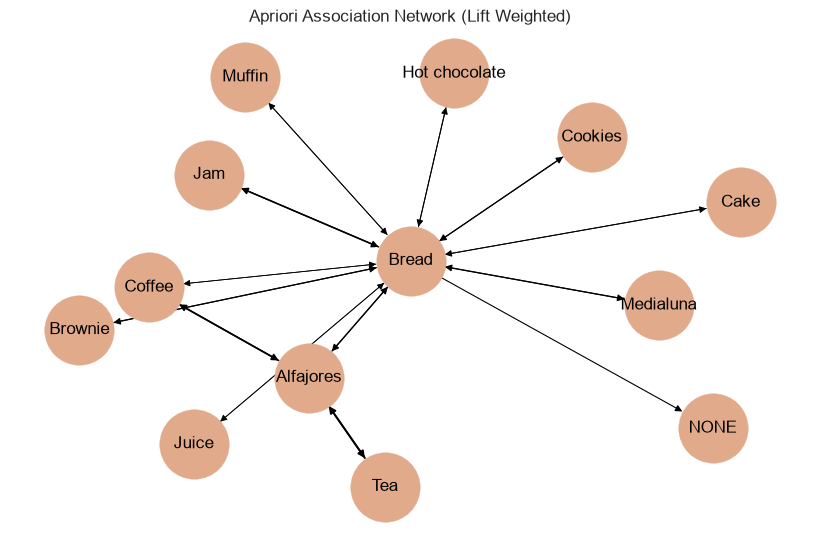

In [170]:

G = nx.DiGraph()
# Add edges (antecedent → consequent) using lift as weight
for _, row in rules.head(25).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure(figsize=(8,5))
pos = nx.spring_layout(G, k=1)

weights = [G[u][v]['weight'] for u,v in G.edges()]

# Draw network
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color='#E1AB8B',
    width=weights,
    arrows=True
)
plt.title("Apriori Association Network (Lift Weighted)")
plt.show()

This visualization constructs a network of products where each node represents an item and each connection between nodes represents an association rule derived from the Apriori algorithm, while the thickness of the connections is scaled based on lift to highlight stronger-than-random purchasing relationships between products.

The association network identifies Bread as the central item, showing the strongest associations with several products, including Coffee, Cake, Cookies, Juice, Brownie, and Hot Chocolate. This indicates that Bread is the most frequently co-purchased item and plays a key role in customer purchasing patterns.

## Top Rules by Lift

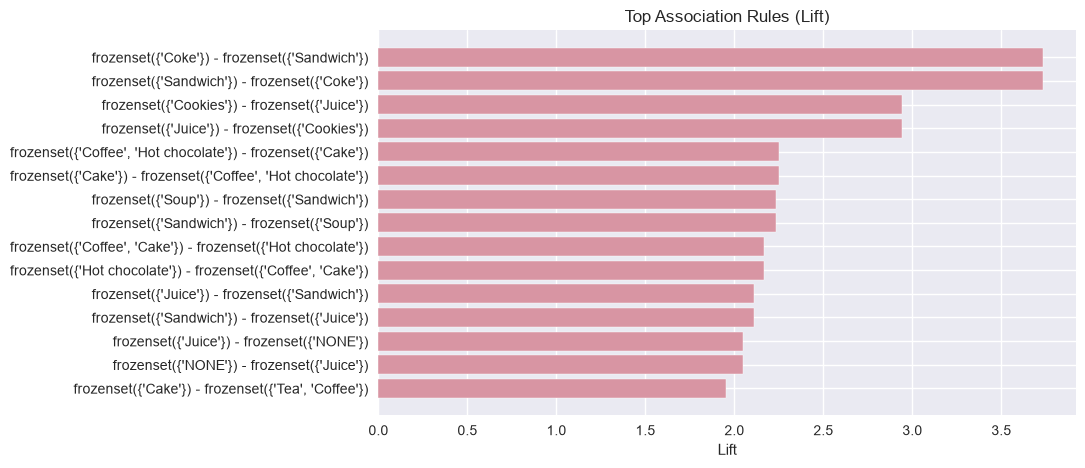

In [173]:
# Select top rules by lift
top_rules = rules.sort_values('lift', ascending=True).tail(15)
# Create readable labels for antecedent → consequent rules
labels = top_rules['antecedents'].astype(str) + " - " + top_rules['consequents'].astype(str)

plt.figure(figsize=(9,5))
plt.barh(labels, top_rules['lift'], color='#D895A3', edgecolor='white')
plt.title("Top Association Rules (Lift)")
plt.xlabel("Lift")
plt.show()

**Key Takeaways:**

- Strongest Pattern: Coke and Sandwich form the most powerful combo (Lift 3.5). These two items are bought together far more often than expected by chance.
- Second Strongest: Cookies and Juice (Lift 3.0)  another very reliable pairing.
- Drink + Dessert trend: Combinations involving Coffee, Hot Chocolate, and Cake show solid associations (Lift 2.5 - 2.7).
- Most rules are bidirectional (A-B and B-A both appear with similar strength), which is common when items are strongly linked.

## Sankey flow diagram (purchase transition flow)

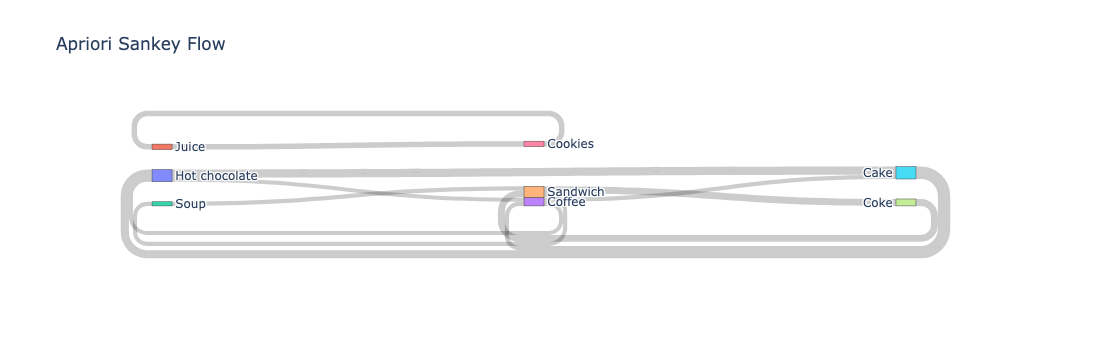

In [178]:
# Top rules by lift
top_rules = rules.sort_values('lift', ascending=False).head(10)

# Unique labels for nodes
labels = list(set(top_rules['antecedents'].explode().tolist() +
                  top_rules['consequents'].explode().tolist()))

label_map = {v: i for i, v in enumerate(labels)}

# Build Sankey links
source, target, value = [], [], []

for _, row in top_rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            source.append(label_map[a])
            target.append(label_map[c])
            value.append(row['lift'])

# Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels),
    link=dict(source=source, target=target, value=value)
)])

fig.update_layout(title="Apriori Sankey Flow")
fig.show()

This Sankey diagram visualizes how customer purchasing behavior flows from one product to another based on association rules, where the width of each flow represents the strength of the relationship measured through lift, thereby allowing us to understand sequential or directional buying patterns across products.

## Support vs Confidence vs Lift (3d view)

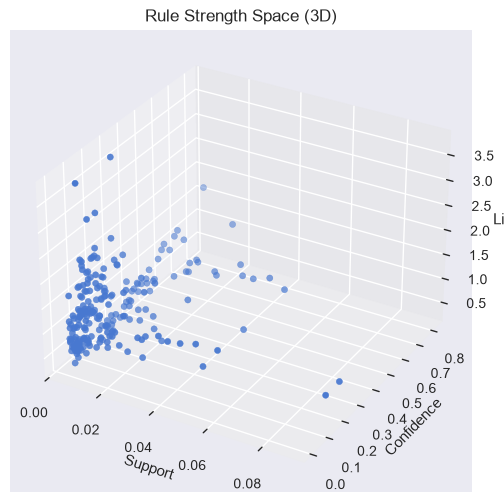

In [181]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rules['support'],
    rules['confidence'],
    rules['lift']
)

ax.set_xlabel("Support")
ax.set_ylabel("Confidence")
ax.set_zlabel("Lift")
ax.set_title("Rule Strength Space (3D)")
plt.show()

This three-dimensional visualization plots each association rule in a multi-metric space where support represents frequency, confidence represents reliability, and lift represents strength, thereby allowing us to observe how strong and rare or frequent different rules are in relation to each other.

## Rule quality score heatmap

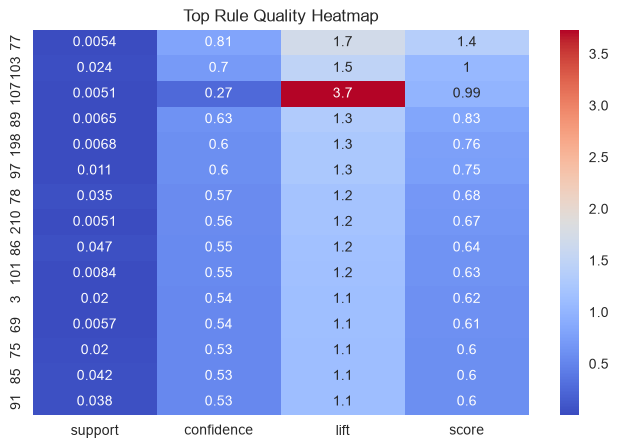

In [77]:

rules['score'] = rules['lift'] * rules['confidence']

top = rules.sort_values('score', ascending=False).head(15)
plt.figure(figsize=(8,5))
sns.heatmap(
    top[['support','confidence','lift','score']],
    annot=True,
    cmap="coolwarm"
)
plt.title("Top Rule Quality Heatmap")
plt.show()

**Key Takeaways:**

**The standout rule (bright red cell):**
One rule has Lift = 3.7 — this is the strongest lift in the entire set.
This likely corresponds to the Coke - Sandwich (or similar) rule from your first chart.

**Support is generally low (0.005 – 0.047):**
Most rules occur in less than 5% of transactions. This is normal in association rule mining — only a few combinations are common.

**Confidence varies widely:**
Ranges from 0.27 to 0.81.
The highest confidence (0.81) suggests a very reliable rule (when you buy the first item, you often buy the second).

Most rules have moderate Lift (1.1 – 1.7), except for that one very strong rule at 3.7.

## Support vs Confidence

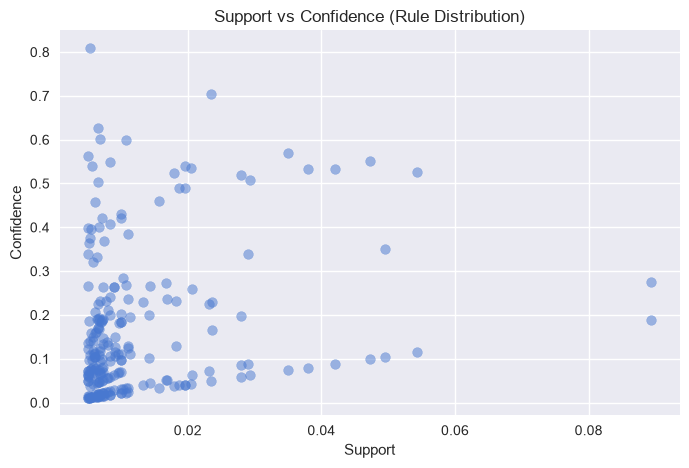

In [182]:
plt.figure(figsize=(8,5))

plt.scatter(
    rules['support'],
    rules['confidence'],
    alpha=0.5
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Rule Distribution)")
plt.show()

Most rules are concentrated in the bottom-left corner:

**Low Support** (< 0.02) and Low-to-Medium Confidence.
This is very typical — most possible rules are rare and not very reliable.

**High Confidence rules** (0.5 – 0.8):
There are several rules with high confidence but relatively low support.
These are reliable but infrequent patterns.

**High Support rules:**
Very few rules have high support (> 0.04). The ones that do tend to have lower confidence.

The "sweet spot" (ideal rules) would be in the top-right area — high support + high confidence. There are only a few points there.

## Item Centrality in Association Rule Network

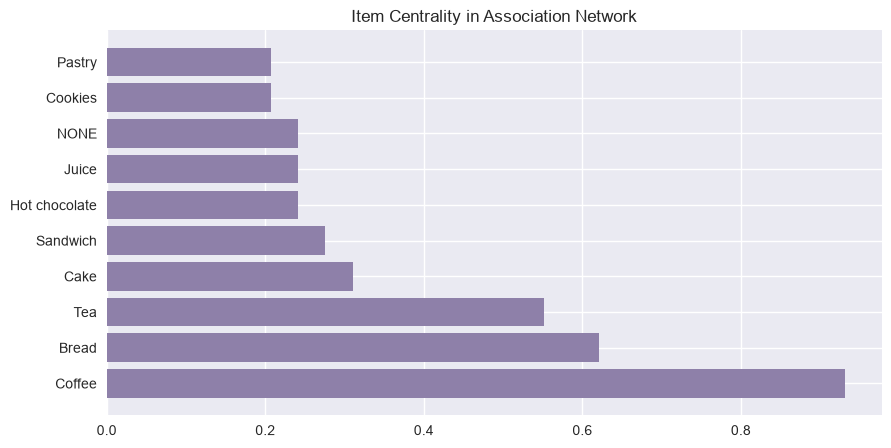

In [185]:
G = nx.Graph()

for _, row in rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c)

centrality = nx.degree_centrality(G)

top = dict(sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(10,5))

# Green bars
plt.barh(list(top.keys()), list(top.values()), color='#8E80A9')

plt.title("Item Centrality in Association Network")
plt.show()

#### **Business Story:**

Coffee is the hero product. It drives many sales and pairs well with Bread, Tea, Cake, etc.

There are strong **combo clusters:**

- Coffee / Tea / Bread / Cake (breakfast/snack cluster)
- Coke / Sandwich (lunch cluster)
- Cookies / Juice (snack cluster)

**Recommendation:** Focus promotions and menu design heavily around Coffee as the anchor item, while leveraging the strong pairs identified earlier.

## Lift Distribution

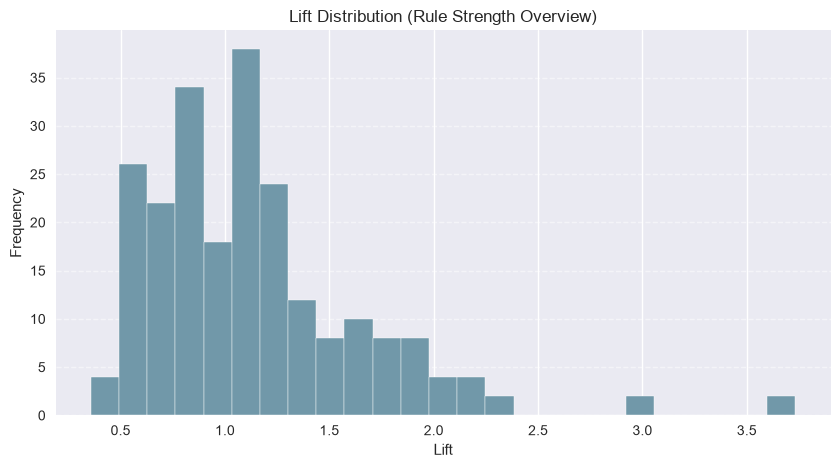

In [192]:
plt.figure(figsize=(10,5))

# Histogram of lift values to show rule strength distribution
plt.hist(rules['lift'], bins=25, color='#7198A9', edgecolor='white')

plt.title("Lift Distribution (Rule Strength Overview)")
plt.xlabel("Lift")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Key Takeaways:**

- Most rules have weak Lift (0.8–1.3) — common but not useful.
- Few rules show strong association (Lift > 2.0).
- Very few exceptional rules (Lift 3.0–3.7), led by Coke - Sandwich.
- Opportunity lies in the right tail: Focus only on high-Lift rules for maximum impact.

**Bottom line**: Ignore average rules. Prioritize the rare, strong ones for promotions and bundling.

## Confidence Distribution

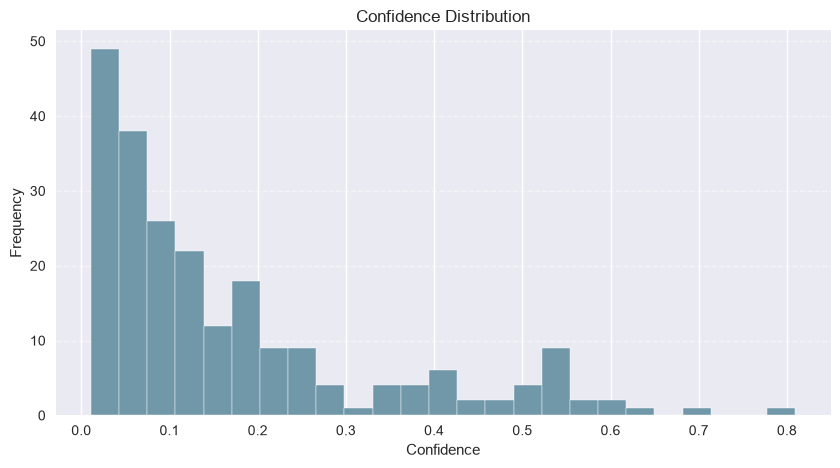

In [193]:
plt.figure(figsize=(10,5))

# Histogram of lift values to show rule strength distribution
plt.hist(rules['confidence'], bins=25, color='#7198A9', edgecolor='white')

plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Key Takeaways:**
- Most rules have low confidence (peak at 0.0–0.1).
- Sharp drop after 0.2 — high-confidence rules are rare.
- Small second peak around 0.5–0.6 shows a few reliable rules.
- Only very few rules exceed 0.7 confidence.
  
**Bottom line:** Most associations are unreliable. Focus on the rare high-confidence rules (especially those also with high Lift).

## Business Summary

The Apriori analysis identified clear purchasing patterns that can be used to improve product bundling, promotions, and store layout. Bread emerged as the central product, frequently purchased with items such as Coffee, Cake, Cookies, Juice, Brownie, and Hot Chocolate, making it an effective anchor product for cross-selling. Additionally, Coke–Sandwich and Cookies–Juice were the strongest item combinations, indicating natural customer buying habits that can be leveraged through bundled offers.

Although most association rules had low support and moderate confidence, a small number exhibited high confidence (up to 0.81) and strong lift (up to 3.7), demonstrating reliable and meaningful purchasing relationships. These high-lift rules represent the greatest business value, while the majority of weaker rules contribute little actionable insight.

Overall, the results suggest that the business should prioritize high-lift, high-confidence product combinations for promotions, meal deals, and shelf placement. Organizing products into customer purchase clusters—such as Breakfast (Bread, Coffee, Cake), Lunch (Coke, Sandwich), and Snacks (Cookies, Juice)—can increase cross-selling opportunities, improve the average basket size, and enhance the overall customer shopping experience.